Reported a = 0.65


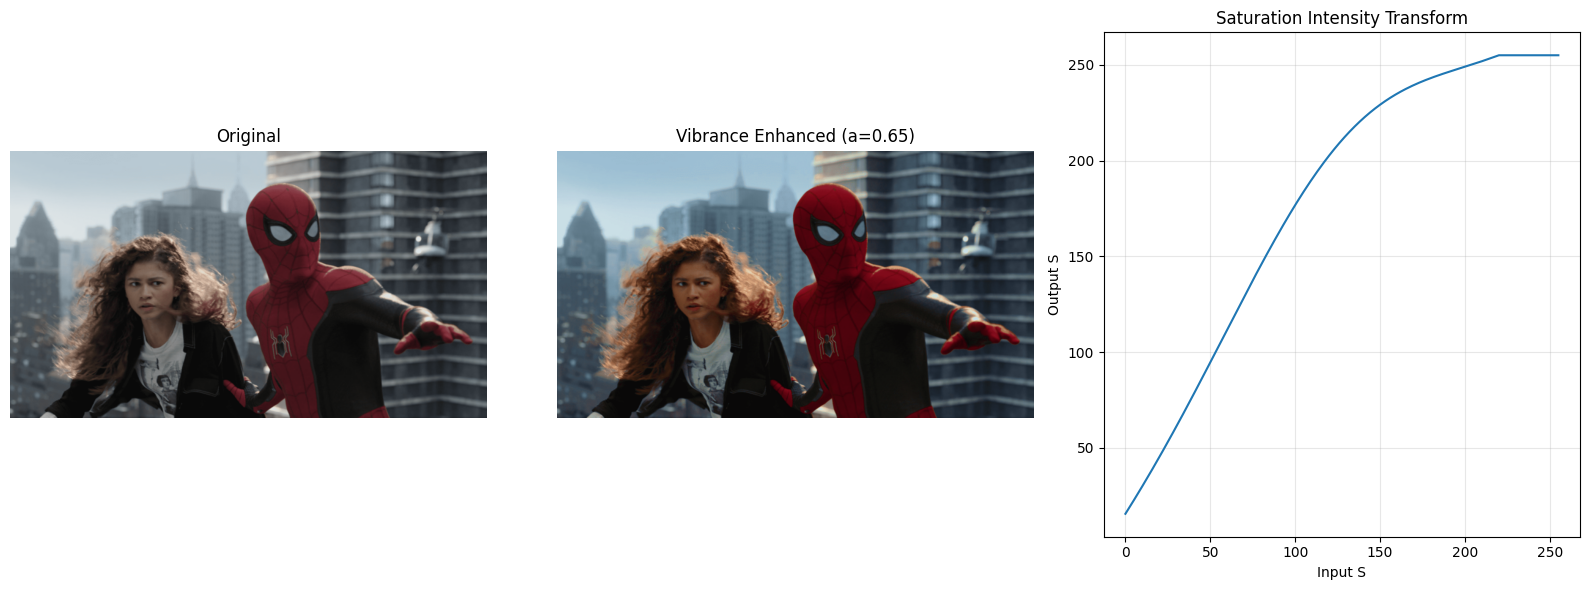

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

bgr = cv2.imread('/content/sample_data/spider.png')
assert bgr is not None, "Image not found."
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

def vibrance_transform_s(s_plane, a=0.6, sigma=70.0, mu=128.0):
    s = s_plane.astype(np.float32)
    bump = a * 128.0 * np.exp(-((s - mu) ** 2) / (2.0 * sigma ** 2))
    out = np.clip(s + bump, 0, 255)
    return out.astype(np.uint8)

a = 0.65
S_vib = vibrance_transform_s(S, a=a, sigma=70.0, mu=128.0)


hsv_vib = cv2.merge([H, S_vib, V])
bgr_vib = cv2.cvtColor(hsv_vib, cv2.COLOR_HSV2BGR)
rgb     = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb_vib = cv2.cvtColor(bgr_vib, cv2.COLOR_BGR2RGB)

print(f"Reported a = {a}")


x = np.arange(0, 256, dtype=np.float32)
y = np.clip(x + a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * 70.0 ** 2)), 0, 255)

plt.figure(figsize=(16,6))

plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(rgb_vib)
plt.title(f"Vibrance Enhanced (a={a})")
plt.axis("off")

plt.subplot(1,3,3)
plt.plot(x, y)
plt.title("Saturation Intensity Transform")
plt.xlabel("Input S")
plt.ylabel("Output S")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
